# El problema de Monge y Kantorovich

Este cuaderno acompaña los **Capítulos 1 y 2** de las notas del curso (*Introducción* y *Existencia de planes óptimos*). Ilustra numéricamente los problemas de Monge y de Kantorovich: el caso discreto con masas iguales (una asignación), el caso discreto general (donde hace falta dividir la masa), el caso continuo, la influencia del costo $c(x,y)=|x-y|^p$, y algunos fenómenos que motivan la relajación de Kantorovich: la no existencia de mapas de Monge, la estructura de vértice de los planes óptimos (teorema de Birkhoff) y la falta de clausura débil del conjunto de mapas.

Usamos la biblioteca [POT (Python Optimal Transport)](https://pythonot.github.io/) para resolver el problema de Kantorovich discreto como un programa lineal (`ot.emd`), y `scipy` para el problema de asignación. Los **ejercicios computacionales** están al final; sus enunciados figuran también en la sección de ejercicios de los capítulos correspondientes de las notas.

## 1. El problema de Monge en el caso discreto

En este ejemplo consideraremos dos conjuntos de $n$ puntos del plano, que representan el origen y el destino de una masa uniformemente distribuida. Cada punto origen debe transportarse a un único punto destino, de modo que cada destino reciba exactamente una unidad de masa. Como función de costo usaremos el *costo cuadrático*
$$
c(x,y)=|x-y|^2
$$

Como vimos en la sección anterior, este problema equivale a buscar una permutación σ que minimice el costo total de transporte.

Primero generaremos aleatoriamente los puntos origen y destino. Luego mostraremos varias asignaciones elegidas al azar y calcularemos el costo asociado a cada una de ellas. Finalmente, resolveremos el problema de optimización utilizando el algoritmo húngaro y compararemos el costo óptimo con los obtenidos mediante asignaciones aleatorias.

La diferencia entre ambas soluciones pone de manifiesto la importancia de resolver el problema de optimización y motiva el estudio de las herramientas teóricas que desarrollaremos en los próximos capítulos.

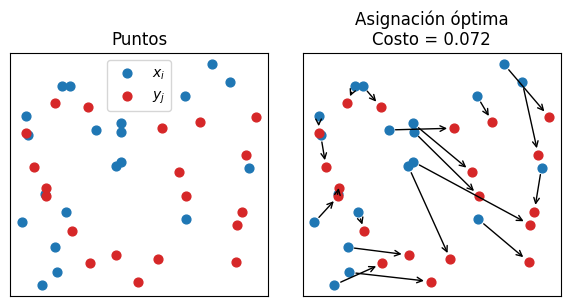

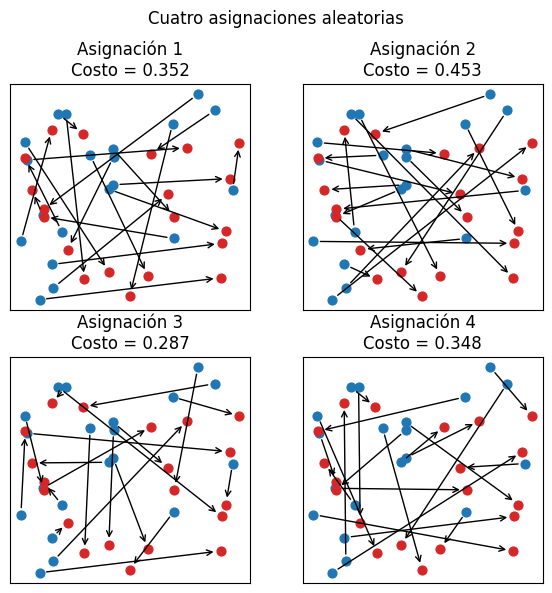

In [10]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

# ==========================================================
# Datos
# ==========================================================

np.random.seed(1)

n = 20

X = np.random.rand(n,2)
Y = np.random.rand(n,2)

C = cdist(X, Y, metric="sqeuclidean")

# ==========================================================
# Funciones auxiliares
# ==========================================================

def matching_cost(C, sigma):
    return C[np.arange(len(sigma)), sigma].sum()/len(sigma)


def draw_points(ax):
    ax.scatter(X[:,0], X[:,1],
               s=40,
               color="tab:blue",
               label=r"$x_i$")

    ax.scatter(Y[:,0], Y[:,1],
               s=40,
               color="tab:red",
               label=r"$y_j$")

    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def draw_matching(ax, sigma):

    draw_points(ax)

    for i,j in enumerate(sigma):
        ax.annotate(
            "",
            xy=Y[j],
            xytext=X[i],
            arrowprops=dict(
                arrowstyle="->",
                color="black",
                lw=1,
                shrinkA=5,
                shrinkB=5,
            ),
        )



# ==========================================================
# 1. Solución óptima
# ==========================================================

rows, cols = linear_sum_assignment(C)

sigma_opt = cols
cost_opt = matching_cost(C, sigma_opt)

fig, axs = plt.subplots(1,2, figsize=(6,3))

draw_points(axs[0])
axs[0].set_title("Puntos")
axs[0].legend()

draw_matching(axs[1], sigma_opt)
axs[1].set_title(f"Asignación óptima\nCosto = {cost_opt:.3f}")

plt.tight_layout()
plt.show()

# ==========================================================
# 2. Cuatro asignaciones aleatorias
# ==========================================================

fig, axs = plt.subplots(2,2, figsize=(6,6))

for k, ax in enumerate(axs.flat):

    sigma = np.random.permutation(n)
    cost = matching_cost(C, sigma)

    draw_matching(ax, sigma)

    ax.set_title(f"Asignación {k+1}\nCosto = {cost:.3f}")

plt.suptitle("Cuatro asignaciones aleatorias")
plt.tight_layout()
plt.show()


## 2. Transporte entre dos densidades: un mapa explícito

Consideremos el problema de transporte óptimo con costo cuadrático

$$
c(x,y)=|x-y|^2,
$$

entre la densidad uniforme sobre el intervalo $[0,1]$,

$$
\rho_0(x)=1_{[0,1]}(x),
$$

y la densidad

$$
\rho_1(x)=2\,1_{[0,\frac12]}(x).
$$

Este ejemplo ilustra cómo un mapa de transporte puede transformar una distribución de masa en otra. En particular, observaremos que el intervalo $[0,1]$ se comprime sobre el intervalo $[0,\tfrac12]$, duplicando la densidad para conservar la masa.

En este punto del curso **todavía no disponemos de herramientas para calcular el mapa óptimo de transporte**. Por este motivo, utilizaremos directamente el mapa

$$
T(x)=\frac{x}{2},
$$

cuya optimalidad para el costo cuadrático será demostrada más adelante al estudiar el problema unidimensional. El objetivo de este ejemplo es únicamente visualizar el efecto que produce un mapa de transporte sobre una distribución continua de masa.

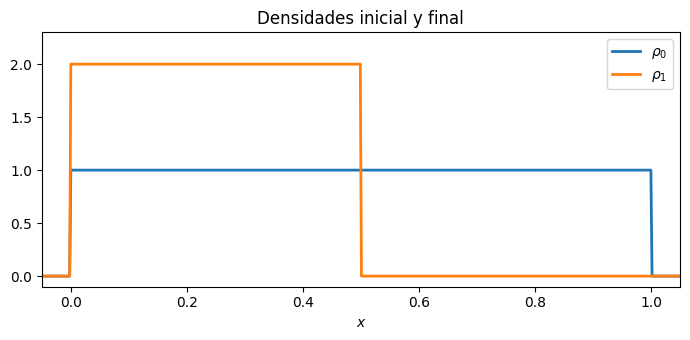

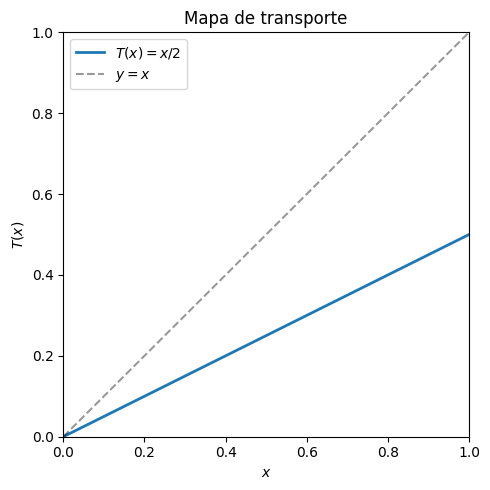

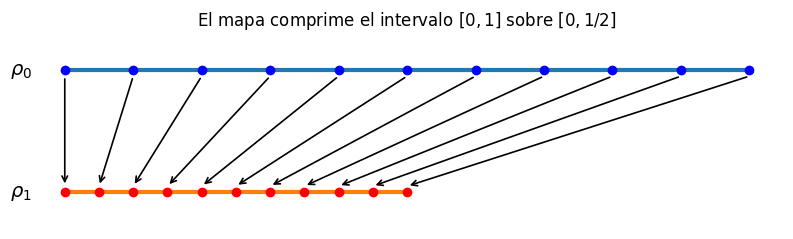

In [11]:
# @title
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Densidades
# ==========================================================

def rho0(x):
    return np.where((0 <= x) & (x <= 1), 1.0, 0.0)

def rho1(x):
    return np.where((0 <= x) & (x <= 0.5), 2.0, 0.0)

# Mapa de transporte
def T(x):
    return x/2

# Malla
x = np.linspace(-0.1,1.1,600)

# ==========================================================
# Figura 1: las densidades
# ==========================================================

fig, ax = plt.subplots(figsize=(7,3.5))

ax.plot(x,rho0(x),lw=2,label=r"$\rho_0$")
ax.plot(x,rho1(x),lw=2,label=r"$\rho_1$")

ax.set_xlim(-0.05,1.05)
ax.set_ylim(-0.1,2.3)
ax.set_xlabel("$x$")
ax.set_title("Densidades inicial y final")
ax.legend()

plt.tight_layout()
plt.show()

# ==========================================================
# Figura 2: el mapa óptimo
# ==========================================================

fig, ax = plt.subplots(figsize=(5,5))

xx=np.linspace(0,1,300)

ax.plot(xx,T(xx),lw=2,label=r"$T(x)=x/2$")
ax.plot(xx,xx,"k--",alpha=.4,label=r"$y=x$")

ax.set_xlim(0,1)
ax.set_ylim(0,1)

ax.set_xlabel("$x$")
ax.set_ylabel("$T(x)$")
ax.set_title("Mapa de transporte")
ax.legend()

plt.tight_layout()
plt.show()

# ==========================================================
# Figura 3: representación del transporte
# ==========================================================

fig, ax = plt.subplots(figsize=(8,2.5))

# intervalos
ax.plot([0,1],[1,1],lw=3)
ax.plot([0,.5],[0,0],lw=3)

# algunos puntos
pts=np.linspace(0,1,11)

for p in pts:

    ax.plot(p,1,'bo')
    ax.plot(T(p),0,'ro')

    ax.annotate(
        "",
        xy=(T(p),0.05),
        xytext=(p,0.95),
        arrowprops=dict(
            arrowstyle="->",
            lw=1.2,
            color="black"
        )
    )

ax.text(-0.08,1,r"$\rho_0$",fontsize=14,va="center")
ax.text(-0.08,0,r"$\rho_1$",fontsize=14,va="center")

ax.set_xlim(-0.05,1.05)
ax.set_ylim(-0.3,1.3)

ax.set_xticks([])
ax.set_yticks([])

ax.set_title("El mapa comprime el intervalo $[0,1]$ sobre $[0,1/2]$")

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

## 3. El problema de Kantorovich en el caso discreto

En el ejemplo anterior estudiamos el problema de Monge cuando todas las masas eran iguales. En ese caso, el transporte óptimo estaba dado por una asignación entre los puntos origen y destino.

Consideremos ahora una situación más general, en la que cada punto lleva asociada una masa diferente. Más precisamente,

$$
\mu=\sum_{i=1}^n a_i\,\delta_{x_i},
\qquad
\nu=\sum_{j=1}^n b_j\,\delta_{y_j},
$$

donde los coeficientes satisfacen

$$
a_i,b_j>0,
\qquad
\sum_{i=1}^n a_i=\sum_{j=1}^n b_j=1.
$$

Tomaremos nuevamente como costo

$$
c(x,y)=|x-y|^2.
$$

En este caso ya no tiene sentido buscar una asignación entre puntos, pues una misma masa puede dividirse y enviarse a distintos destinos. Resolveremos entonces el problema de Kantorovich mediante la función `emd` de la librería **POT (Python Optimal Transport)**, que devuelve el plan de transporte óptimo.

En las figuras siguientes, el tamaño de cada punto es proporcional a la masa que representa y el grosor de cada flecha es proporcional a la cantidad de masa transportada entre el correspondiente par de puntos. De esta manera puede apreciarse claramente el fenómeno de división de masa, una de las diferencias fundamentales entre los problemas de Monge y Kantorovich.

In [12]:
# @title
pip install POT


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 52.9 MB/s eta 0:00:00


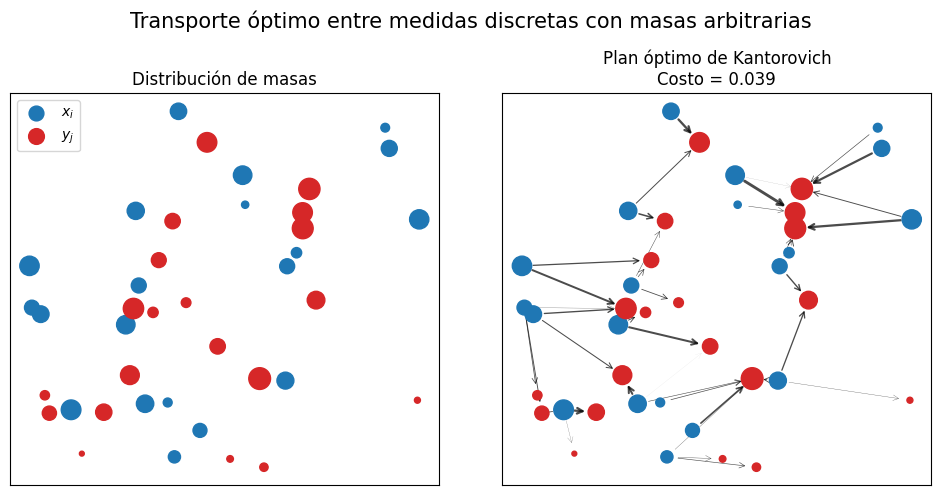

In [18]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import ot
from scipy.spatial.distance import cdist

# ==========================================================
# Datos
# ==========================================================

np.random.seed(3)

n = 20

# Puntos origen y destino
X = np.random.rand(n,2)
Y = np.random.rand(n,2)

# Masas
a = np.random.rand(n)
a /= a.sum()

b = np.random.rand(n)
b /= b.sum()

# Costo cuadrático
C = cdist(X, Y, metric="sqeuclidean")

# ==========================================================
# Plan óptimo de Kantorovich
# ==========================================================

pi = ot.emd(a, b, C)

cost = np.sum(pi*C)

# ==========================================================
# Función para dibujar los puntos
# ==========================================================

scale = 2500

def draw_points(ax):
    ax.scatter(
        X[:,0], X[:,1],
        s=scale*a,
        color="tab:blue",
        label=r"$x_i$",
        zorder=3
    )

    ax.scatter(
        Y[:,0], Y[:,1],
        s=scale*b,
        color="tab:red",
        label=r"$y_j$",
        zorder=3
    )

    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

# ==========================================================
# Figura
# ==========================================================

fig, axs = plt.subplots(1,2, figsize=(10,5))

# ----------------------------------------------------------
# Sólo los puntos
# ----------------------------------------------------------

draw_points(axs[0])

axs[0].set_title("Distribución de masas")
axs[0].legend()

# ----------------------------------------------------------
# Plan óptimo
# ----------------------------------------------------------

draw_points(axs[1])

threshold = 1e-10      # no dibujar masas muy pequeñas
line_scale = 30       # controla el grosor de las flechas

for i in range(n):
    for j in range(n):

        if pi[i,j] > threshold:

            axs[1].annotate(
                "",
                xy=Y[j],
                xytext=X[i],
                arrowprops=dict(
                    arrowstyle="->",
                    color="black",
                    lw=line_scale*pi[i,j],
                    alpha=0.7,
                    shrinkA=8,
                    shrinkB=8
                ),
                zorder=1
            )

axs[1].set_title(f"Plan óptimo de Kantorovich\nCosto = {cost:.3f}")

fig.suptitle("Transporte óptimo entre medidas discretas con masas arbitrarias",
             fontsize=15)

fig.tight_layout(rect=[0,0,1,0.94])

plt.show()

## 4. Influencia del costo en el plan óptimo

Una de las ventajas del enfoque de Kantorovich es que permite estudiar fácilmente el efecto de modificar la función de costo. Consideremos la familia de costos

$$
c(x,y)=|x-y|^p,
\qquad p\ge1.
$$

Manteniendo fijos los puntos origen y destino, así como las masas asociadas a cada uno de ellos, resolveremos el problema de transporte para distintos valores de $p$.

En cada caso representaremos el plan óptimo obtenido. Además, calcularemos la cantidad

$$
W_p(\mu,\nu)
=
\left(
\min_{\pi\in\Pi(\mu,\nu)}
\int |x-y|^p\,d\pi
\right)^{1/p},
$$

que más adelante veremos que define la **distancia de Wasserstein** de orden $p$.

Puede observarse que, aunque los planes óptimos son similares, presentan diferencias sutiles. Al aumentar el valor de $p$, el costo penaliza más fuertemente los transportes de larga distancia, lo que puede modificar la forma en que la masa se distribuye entre los distintos destinos.

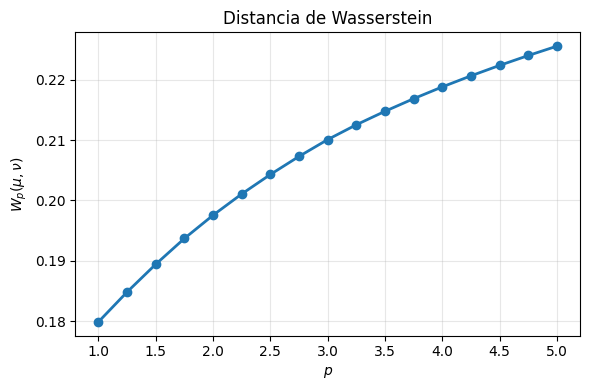

In [20]:
# @title
# ==========================================================
# Comparación para distintos valores de p
# ==========================================================

dist2 = cdist(X, Y, metric="sqeuclidean")

p_values = np.linspace(1,5,17)   # 1, 1.25, ..., 5

wasserstein = []

for p in p_values:

    C = dist2**(p/2)

    pi = ot.emd(a, b, C)

    cost = np.sum(pi*C)
    Wp = cost**(1/p)

    wasserstein.append(Wp)


# ==========================================================
# Gráfico
# ==========================================================

plt.figure(figsize=(6,4))

plt.plot(p_values, wasserstein, "o-", lw=2)

plt.xlabel(r"$p$")
plt.ylabel(r"$W_p(\mu,\nu)$")
plt.title("Distancia de Wasserstein")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

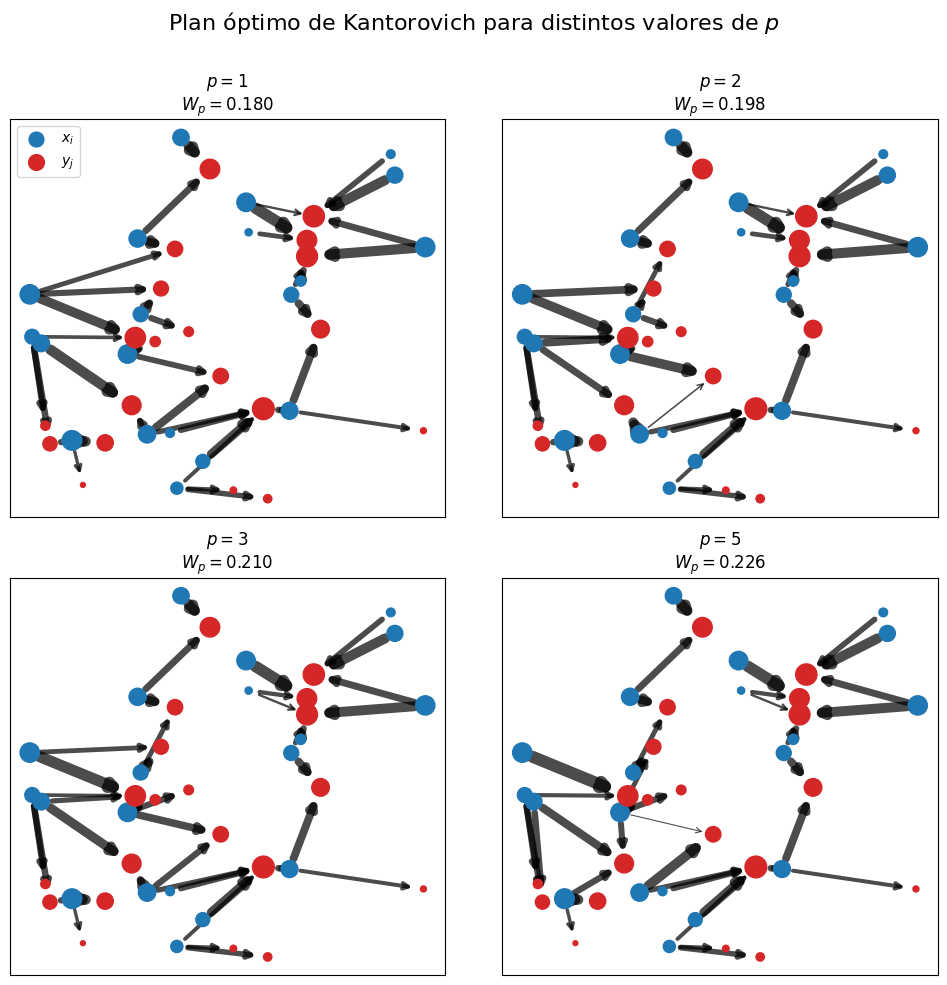

In [22]:
# @title
# ==========================================================
# Comparación de planes óptimos para distintos valores de p
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import ot
from scipy.spatial.distance import cdist

# Distancias al cuadrado (se calculan una sola vez)
dist2 = cdist(X, Y, metric="sqeuclidean")

# Valores de p
p_values = [1, 2, 3, 5]

fig, axs = plt.subplots(2, 2, figsize=(10,10))

line_scale = 30
point_scale = 2500

for ax, p in zip(axs.flat, p_values):

    # Costo
    C = dist2**(p/2)

    # Plan óptimo
    pi = ot.emd(a, b, C)

    # Costo y Wasserstein
    cost = np.sum(pi*C)
    Wp = cost**(1/p)

    # Puntos
    ax.scatter(
        X[:,0], X[:,1],
        s=point_scale*a,
        color="tab:blue",
        label=r"$x_i$",
        zorder=3
    )

    ax.scatter(
        Y[:,0], Y[:,1],
        s=point_scale*b,
        color="tab:red",
        label=r"$y_j$",
        zorder=3
    )

    # Flechas
    for i in range(n):
        for j in range(n):

            if pi[i,j] > 1e-10:

                ax.annotate(
                    "",
                    xy=Y[j],
                    xytext=X[i],
                    arrowprops=dict(
                        arrowstyle="->",
                        color="black",
                        lw=0.3 + line_scale*np.sqrt(pi[i,j]),
                        alpha=0.7,
                        shrinkA=8,
                        shrinkB=8
                    ),
                    zorder=1
                )

    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title(
        rf"$p={p}$" "\n"
        rf"$W_p={Wp:.3f}$"
    )

axs[0,0].legend()

fig.suptitle(
    "Plan óptimo de Kantorovich para distintos valores de $p$",
    fontsize=16
)

fig.tight_layout(rect=[0,0,1,0.96], h_pad=3)

plt.show()


## 5. El problema de Kantorovich para medidas continuas

Hasta ahora estudiamos el problema de Kantorovich para medidas discretas, donde las masas estaban concentradas en un número finito de puntos. En este ejemplo consideraremos dos medidas absolutamente continuas sobre el intervalo $[0,1]$.

Tomaremos dos densidades de probabilidad

$$
d\mu(x)=\rho_0(x)\,dx,
\qquad
d\nu(x)=\rho_1(x)\,dx,
$$

y el costo cuadrático

$$
c(x,y)=|x-y|^2.
$$

Para resolver numéricamente el problema discretizaremos el intervalo mediante una grilla uniforme. Cada densidad se aproximará por una medida discreta cuyos pesos son proporcionales a los valores de la densidad en los puntos de la grilla.

Una vez obtenidas estas aproximaciones discretas, utilizaremos nuevamente la función `emd` de la librería **POT (Python Optimal Transport)** para calcular el plan óptimo de Kantorovich.

En la figura de la izquierda se representan las dos densidades de probabilidad. En la de la derecha se muestra el plan óptimo de transporte, representado como una matriz cuyos coeficientes indican cuánta masa es transportada desde cada punto de la grilla hacia cada uno de los puntos destino. Esta matriz puede interpretarse como una aproximación discreta del plan de transporte óptimo.

W_2 = 0.1861


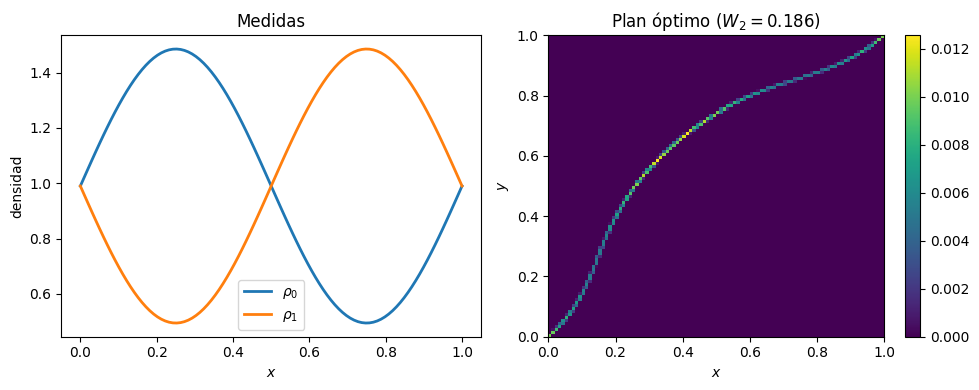

In [28]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import ot
from scipy.spatial.distance import cdist

# ==========================================================
# Discretización del intervalo
# ==========================================================

N = 100

x = np.linspace(0,1,N)
dx = x[1]-x[0]

# ==========================================================
# Densidades
# ==========================================================

rho0 = 1 + 0.5*np.sin(2*np.pi*x)
rho1 = 1 - 0.5*np.sin(2*np.pi*x)

# Normalización
rho0 /= np.sum(rho0)*dx
rho1 /= np.sum(rho1)*dx

# Masas discretas
a = rho0*dx
b = rho1*dx

# ==========================================================
# Matriz de costos
# ==========================================================

p = 2

dist2 = cdist(x[:,None], x[:,None], metric="sqeuclidean")
C = dist2**(p/2)

# ==========================================================
# Plan óptimo
# ==========================================================

pi = ot.emd(a,b,C)

cost = np.sum(pi*C)
Wp = cost**(1/p)

print(f"W_{p} = {Wp:.4f}")

# ==========================================================
# Figura
# ==========================================================

fig,axs = plt.subplots(1,2,figsize=(10,4))

# ---------------------------------------
# Densidades
# ---------------------------------------

axs[0].plot(x,rho0,lw=2,label=r"$\rho_0$")
axs[0].plot(x,rho1,lw=2,label=r"$\rho_1$")

axs[0].set_xlabel("$x$")
axs[0].set_ylabel("densidad")
axs[0].legend()
axs[0].set_title("Medidas")

# ---------------------------------------
# Plan de transporte
# ---------------------------------------

im = axs[1].imshow(
    pi.T,
    origin="lower",
    extent=[0,1,0,1],
    aspect="auto"
)

axs[1].set_xlabel("$x$")
axs[1].set_ylabel("$y$")
axs[1].set_title(rf"Plan óptimo ($W_{p}={Wp:.3f}$)")

plt.colorbar(im, ax=axs[1])

plt.tight_layout()
plt.show()

### Un plan de Kantorovich inducido por un mapa

La figura obtenida resulta especialmente interesante. Puede observarse que el plan óptimo no distribuye la masa sobre una región bidimensional del plano $[0,1]\times[0,1]$, sino que está prácticamente concentrado sobre una curva.

Esto sugiere que, para cada punto de partida $x$, toda la masa es enviada a un único punto destino $y=T(x)$. En otras palabras, el plan óptimo parece estar soportado sobre el gráfico de una función,

$$
\{(x,T(x)):\;x\in[0,1]\},
$$

lo que indica que el plan de Kantorovich está inducido por un **mapa de transporte**. En ese caso, el problema de Kantorovich y el problema de Monge tienen la misma solución.

En una dimensión, este fenómeno no es casual. Más adelante veremos que, bajo hipótesis muy generales y para costos de la forma

$$
c(x,y)=|x-y|^p,\qquad p>1,
$$

el plan óptimo está efectivamente inducido por un único mapa de transporte.

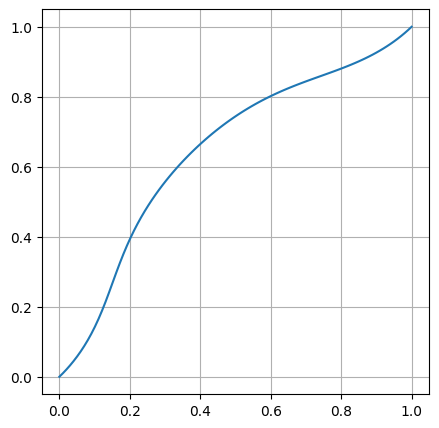

In [29]:
# @title
# Calculamos las funciones de distribución acumulada (CDF) de mu y nu.
# Como las medidas son discretas con masas a_i y b_j, las CDF son escalonadas.
# Agregamos un 0 al comienzo para que F(x_0^-) = 0.
F0 = np.concatenate(([0], np.cumsum(a)))  # CDF de mu
F1 = np.concatenate(([0], np.cumsum(b)))  # CDF de nu

# El mapa óptimo en 1D es T = F_nu^{-1} ∘ F_mu,
# donde F_nu^{-1} es la pseudoinversa (cuantil generalizado) de F_nu.
# np.interp(F0[:-1], F1[:-1], x) evalúa numéricamente F_nu^{-1}(F_mu(x_i)).
T = np.interp(F0[:-1], F1[:-1], x)

plt.figure(figsize=(5,5))
plt.plot(x, T, lw=2)
plt.xlabel(r"$x$")
plt.ylabel(r"$T(x)$")
plt.title(r"Mapa óptimo $T = F_\nu^{-1} \circ F_\mu$")
plt.grid(True)
plt.tight_layout()
plt.show()


## 6. Cuando no existe ningún mapa de Monge

El ejemplo más simple de la diferencia entre Monge y Kantorovich es $\mu=\delta_0$ y $\nu=\frac12(\delta_{-1}+\delta_1)$: un mapa $T$ envía toda la masa de $\mu$ a un único punto $T(0)$, así que $T_\#\mu$ es una masa de Dirac y nunca puede ser $\nu$. El conjunto de mapas de transporte es **vacío**, y el problema de Monge no tiene sentido. El problema de Kantorovich, en cambio, tiene exactamente un plan admisible, que divide la masa en dos.

Un fenómeno relacionado ocurre cuando $\mu$ y $\nu$ tienen la misma cantidad de átomos pero masas incompatibles: por ejemplo $\mu=\frac13\delta_{x_1}+\frac23\delta_{x_2}$ y $\nu=\frac12\delta_{y_1}+\frac12\delta_{y_2}$. Verificamos con POT que el plan óptimo divide la masa del átomo pesado, y que **no** hay ningún plan inducido por un mapa (un mapa entre estos soportes es una de las cuatro funciones $\{x_1,x_2\}\to\{y_1,y_2\}$, y ninguna transporta $\mu$ en $\nu$).

In [ ]:
# @title
import numpy as np, ot, itertools

# --- mu = delta_0, nu = (delta_{-1} + delta_1)/2
a0 = np.array([1.0]); X0 = np.array([[0.0]])
b0 = np.array([0.5, 0.5]); Y0 = np.array([[-1.0], [1.0]])
pi0 = ot.emd(a0, b0, (X0 - Y0.T)**2)
print("Plan de Kantorovich entre delta_0 y (delta_-1 + delta_1)/2:\n", pi0)
print("Pi(mu,nu) tiene un solo elemento y no proviene de un mapa: la fila tiene dos entradas positivas.\n")

# --- masas incompatibles
a1 = np.array([1/3, 2/3]); b1 = np.array([1/2, 1/2])
X1 = np.array([[0.0], [1.0]]); Y1 = np.array([[0.2], [0.9]])
C1 = (X1 - Y1.T)**2
pi1 = ot.emd(a1, b1, C1)
print("Plan óptimo con masas (1/3, 2/3) -> (1/2, 1/2):\n", pi1)

# los cuatro mapas posibles {x1,x2} -> {y1,y2}
print("\nMapas T: {x1,x2} -> {y1,y2} y la medida T_# mu que producen:")
for T in itertools.product([0, 1], repeat=2):
    Tmu = np.zeros(2)
    for i, j in enumerate(T):
        Tmu[j] += a1[i]
    print(f"  T = (y{T[0]+1}, y{T[1]+1}):  T_# mu = {Tmu}  ->  {'= nu' if np.allclose(Tmu, b1) else 'distinto de nu'}")

## 7. El conjunto $\Pi(\mu,\nu)$ y sus vértices

En el caso discreto, $\Pi(\mu,\nu)$ es un **politopo** (un conjunto convexo, compacto, definido por igualdades y desigualdades lineales) y el funcional de Kantorovich es lineal, así que el mínimo se alcanza en un **vértice**. Esto tiene dos consecuencias que se ven muy bien numéricamente.

Primero, el ejemplo más pequeño posible: $\mu=\nu=\frac12(\delta_0+\delta_1)$. Los planes son las matrices $\bigl(\begin{smallmatrix}t & \frac12-t\\ \frac12-t & t\end{smallmatrix}\bigr)$ con $t\in[0,\frac12]$: un segmento. El costo es una función afín de $t$, así que el mínimo está en un extremo. Los extremos son los dos planes inducidos por mapas (la identidad y el intercambio); el punto medio $t=\frac14$ es el plan del Ejercicio 1.7 de las notas, que no proviene de ningún mapa.

Segundo, en general un vértice de $\Pi(\mu,\nu)$ tiene a lo sumo $n+m-1$ entradas no nulas (Ejercicio 3.4), y cuando las masas son uniformes e iguales los vértices son exactamente las matrices de permutación divididas por $n$ (teorema de Birkhoff). Verificamos ambas cosas con el solver: el plan que devuelve `ot.emd` es siempre un vértice.

In [ ]:
# @title
import matplotlib.pyplot as plt

# --- el segmento Pi(mu,nu) para mu = nu = (delta_0 + delta_1)/2
ts = np.linspace(0, 0.5, 101)
costo_cuad = [(0.5 - t)*2*1.0 for t in ts]           # c = |x-y|^2: las entradas fuera de la diagonal cuestan 1
costo_max  = [t*2*0 + (0.5 - t)*2*(-1) for t in ts]    # c = -|x-y|^2 (maximizar la distancia)

plt.figure(figsize=(6, 3.5))
plt.plot(ts, costo_cuad, label=r'$c=|x-y|^2$')
plt.plot(ts, costo_max, label=r'$c=-|x-y|^2$')
plt.axvline(0.25, color='gray', ls=':', label=r'$t=1/4$: plan producto (no es un mapa)')
plt.xlabel('t'); plt.ylabel('costo del plan'); plt.legend(); plt.title(r'El costo es afín en $t$: el mínimo está en un vértice')
plt.show()

# --- vértices: número de entradas no nulas
rng = np.random.default_rng(0)
n, m = 20, 30
X = rng.random((n, 2)); Y = rng.random((m, 2))
a = rng.dirichlet(np.ones(n)); b = rng.dirichlet(np.ones(m))
C = cdist(X, Y, metric="sqeuclidean")
pi = ot.emd(a, b, C)
print(f"Masas genéricas: entradas no nulas del plan óptimo = {np.sum(pi > 1e-12)}  (cota: n+m-1 = {n+m-1})")

# --- masas uniformes e iguales: el plan es una permutación
n = 25
X = rng.random((n, 2)); Y = rng.random((n, 2))
a = b = np.ones(n)/n
pi = ot.emd(a, b, cdist(X, Y, metric="sqeuclidean"))
es_perm = np.allclose(np.sort(pi, axis=1)[:, -1], 1/n) and np.all(np.sum(pi > 1e-12, axis=1) == 1)
print(f"Masas uniformes: ¿el plan óptimo es una matriz de permutación / n?  {es_perm}")
sigma = np.argmax(pi, axis=1)
rows, cols = linear_sum_assignment(cdist(X, Y, metric="sqeuclidean"))
print("¿Coincide con la asignación óptima de scipy?", np.array_equal(sigma, cols))

### No unicidad del plan óptimo

El mínimo de una función lineal sobre un politopo puede alcanzarse en más de un vértice (y entonces en toda la cara que los une). Un ejemplo con costo $|x-y|$ en dimensión uno: $\mu$ uniforme en $\{0,1,2,3\}$ y $\nu$ uniforme en $\{1,2,3,4\}$. El costo óptimo es $1$ (toda la masa debe moverse en promedio una unidad hacia la derecha), y lo alcanzan muchos planes: mover cada átomo un lugar, o mover sólo el $0$ hasta el $4$, entre otros. El solver devuelve **uno** de ellos, y cuál devuelve depende de detalles de la implementación; perturbando levemente el costo obtenemos distintos vértices óptimos.

In [ ]:
# @title
x = np.arange(4.0); y = np.arange(1.0, 5.0)
a = b = np.ones(4)/4
C = np.abs(x[:, None] - y[None, :])
pi = ot.emd(a, b, C)
print("Plan que devuelve el solver (costo = %.4f):\n" % np.sum(C*pi), np.round(pi*4).astype(int), "  (x4)")

# planes alternativos escritos a mano, todos con costo 1
pi_shift = np.eye(4)/4
pi_salto = np.zeros((4, 4)); pi_salto[0, 3] = 1/4; pi_salto[1, 0] = pi_salto[2, 1] = pi_salto[3, 2] = 1/4
for nombre, p in [("desplazar todos un lugar", pi_shift), ("saltar 0 -> 4", pi_salto), ("promedio de ambos", (pi_shift + pi_salto)/2)]:
    print(f"{nombre:>28}: costo = {np.sum(C*p):.4f}, marginales correctas: {np.allclose(p.sum(1), a) and np.allclose(p.sum(0), b)}")

# perturbaciones del costo: distintos vértices óptimos
print("\nVértices óptimos distintos obtenidos perturbando el costo (soportes):")
vistos = set()
for k in range(20):
    Ck = C + 1e-9*rng.random(C.shape)
    pk = ot.emd(a, b, Ck)
    sop = tuple(map(tuple, (pk > 1e-12).astype(int)))
    if sop not in vistos and abs(np.sum(C*pk) - 1) < 1e-9 and len(vistos) < 4:
        vistos.add(sop); print(np.array(sop), "\n")

## 8. Costos cóncavos: $p<1$

En la Sección 4 vimos el efecto de $p\ge1$. Para $0<p<1$ el costo $|x-y|^p$ es **cóncavo** en la distancia y el comportamiento cambia cualitativamente: conviene dejar quieta la masa común de $\mu$ y $\nu$ y mover el resto, aun a costa de cruces. El ejemplo más pequeño es $\mu=\frac12(\delta_0+\delta_1)$, $\nu=\frac12(\delta_1+\delta_2)$: para $p\ge1$ el plan óptimo mueve cada átomo un lugar ($0\to1$, $1\to2$); para $p<1$ conviene dejar el $1$ donde está y mandar el $0$ hasta el $2$. En el caso continuo, con las densidades de la Sección 5, el plan óptimo para $p=1/2$ tiene una parte concentrada en la diagonal $y=x$ (la masa común) y el resto se reparte lejos de ella. Éste es el tema del Ejercicio 8.5 de las notas.

In [ ]:
# @title
# --- dos átomos
x = np.array([[0.0], [1.0]]); y = np.array([[1.0], [2.0]]); a = b = np.array([0.5, 0.5])
for p in [2, 1, 0.5]:
    C = np.abs(x - y.T)**p
    pi = ot.emd(a, b, C)
    print(f"p = {p}: plan óptimo (x2) =", np.round(2*pi).astype(int).tolist(), f" costo = {np.sum(C*pi):.4f}")

# --- caso continuo: mismas densidades de la Sección 5
N = 100
xg = np.linspace(0, 1, N); dx = xg[1] - xg[0]
rho0 = 1 + 0.5*np.sin(2*np.pi*xg); rho1 = 1 - 0.5*np.sin(2*np.pi*xg)
a = rho0/rho0.sum(); b = rho1/rho1.sum()
D = np.abs(xg[:, None] - xg[None, :])

fig, axs = plt.subplots(1, 3, figsize=(13, 4))
for ax, p in zip(axs, [2, 1, 0.5]):
    pi = ot.emd(a, b, D**p)
    ax.imshow(pi.T, origin="lower", extent=[0, 1, 0, 1], cmap="Blues")
    masa_diag = np.trace(pi)
    ax.set_title(f"p = {p}:  masa en la diagonal = {masa_diag:.3f}")
    ax.set_xlabel("x"); ax.set_ylabel("y")
plt.suptitle("Para p<1 la masa común se queda quieta y el resto se mueve lejos"); plt.tight_layout(); plt.show()

## 9. Los mapas no son débilmente cerrados

El Capítulo 2 resuelve la existencia de planes óptimos con el método directo: $\Pi(\mu,\nu)$ es débilmente compacto y el costo es semicontinuo inferiormente. El mismo argumento **no** funciona para el problema de Monge porque el conjunto de planes inducidos por mapas no es cerrado. El ejemplo del Ejercicio 2.3: las funciones "diente de sierra" $f_n(x)=nx \bmod 1$ preservan la medida de Lebesgue en $[0,1]$, pero los planes $\pi_n=(\mathrm{id},f_n)_\#\mathcal L^1$ convergen débilmente al plan producto $\mathcal L^1\otimes\mathcal L^1$, que no proviene de ningún mapa. Lo vemos con histogramas bidimensionales de $(x,f_n(x))$, y verificamos que el costo $\int|x-f_n(x)|^2dx$ converge a $\int|x-y|^2\,d(\mathcal L^1\otimes\mathcal L^1)=1/6$, como corresponde a la continuidad del funcional de Kantorovich para costos continuos y acotados.

In [ ]:
# @title
xs = rng.random(200_000)
fig, axs = plt.subplots(1, 4, figsize=(15, 4))
for ax, n in zip(axs, [1, 2, 5, 40]):
    fn = (n*xs) % 1.0
    ax.hist2d(xs, fn, bins=40, range=[[0, 1], [0, 1]], cmap="Blues")
    ax.set_title(fr"$\pi_n=(\mathrm{{id}},f_n)_\#\mathcal{{L}}^1$,  n = {n}"); ax.set_xlabel("x"); ax.set_ylabel(r"$f_n(x)$")
plt.tight_layout(); plt.show()

print(f"{'n':>5} {'∫|x-f_n(x)|² dx':>18}   (límite: 1/6 = {1/6:.4f})")
for n in [1, 2, 5, 10, 40, 200]:
    fn = (n*xs) % 1.0
    print(f"{n:>5} {np.mean((xs - fn)**2):>18.4f}")

## Ejercicios computacionales

Los enunciados siguientes figuran también en las notas, en la sección de ejercicios del Capítulo 2.

1. **Asignación y Kantorovich.** Para $n$ puntos con masas uniformes, verificar que `ot.emd` devuelve siempre una matriz de permutación dividida por $n$ y que coincide (en costo) con `linear_sum_assignment`. Para masas genéricas, contar las entradas no nulas del plan óptimo y comprobar la cota $n+m-1$. Construir un ejemplo con $n=m=3$ en el que el plan óptimo tenga exactamente $5$ entradas no nulas, y otro en el que tenga menos.

2. **El segmento $\Pi(\mu,\nu)$.** Para $\mu=\nu=\frac12(\delta_0+\delta_1)$ y los costos $c=|x-y|^2$, $c=\mathbf 1_{x\ne y}$ y $c=-|x-y|^2$, graficar el costo como función del parámetro $t$ del segmento e identificar todos los planes óptimos en cada caso. ¿Para qué costo son óptimos todos los planes?

3. **Birkhoff.** Generar una matriz biestocástica $M$ como combinación convexa aleatoria de cinco permutaciones. Para un costo aleatorio $C$, comprobar que el plan óptimo del LP es una permutación y que $\langle C,M\rangle$ es estrictamente mayor que el óptimo (salvo coincidencias). Implementar la descomposición de Birkhoff: encontrar una permutación $\sigma$ con $M_{i\sigma(i)}>0$ para todo $i$ (usar `linear_sum_assignment` sobre $-\log M$), restar $t\,\pi^\sigma$ con $t=\min_iM_{i\sigma(i)}$ y repetir hasta llegar a cero. ¿Cuántas permutaciones aparecen?

4. **Costos cóncavos.** Con las densidades de la Sección 5, calcular la masa que el plan óptimo deja en la diagonal $\{y=x\}$ como función de $p\in(0,2]$ y graficarla. Explicar el salto en $p=1$ usando la Proposición sobre costos convexos no estrictos del Capítulo 8 y el Ejercicio 8.5.

5. **Convergencia débil de planes.** Con las funciones diente de sierra $f_n$, verificar numéricamente que $\int\phi(x)\psi(f_n(x))\,dx\to\int\phi\int\psi$ para varias $\phi,\psi$ continuas (por ejemplo, polinomios y senos). Repetir con $f_n(x)=x+\frac1n \bmod 1$: ¿a qué plan convergen ahora los $\pi_n$? ¿Está inducido por un mapa?